In [146]:
#Importar librerías
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import skforecast
from sklearn.metrics import mean_squared_error, mean_absolute_error
import warnings
from sklearn.model_selection import train_test_split
from skforecast.recursive import ForecasterRecursive
from skforecast.preprocessing import RollingFeatures
import pmdarima as pm
from pmdarima import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.seasonal import seasonal_decompose
import plotly.graph_objects as go
from statsmodels.graphics.tsaplots import plot_acf,plot_pacf
from sklearn.ensemble import RandomForestRegressor
from skforecast.recursive import ForecasterEquivalentDate
from skforecast.model_selection import backtesting_forecaster
from skforecast.model_selection import TimeSeriesFold
from lightgbm import LGBMRegressor
from skforecast.model_selection import bayesian_search_forecaster
from skforecast.direct import ForecasterDirect
import datetime
from datetime import datetime, timedelta

In [147]:
# Leer archivo CSV con separador punto y coma (;)
datos = pd.read_csv("demanda.csv", sep=";")

# Mostrar las primeras 5 filas
print(datos.head())

         date  store  item  sales
0  01/01/2013      1     1     13
1  02/01/2013      1     1     11
2  03/01/2013      1     1     14
3  04/01/2013      1     1     13
4  05/01/2013      1     1     10


In [148]:
# Filtrar solo el producto 1 y la tienda 1
datos = datos[(datos['item'] == 1) & (datos['store'].isin([1]))]

# Convertir la columna 'date' a datetime con formato día/mes/año
datos['date'] = pd.to_datetime(datos['date'], format='%d/%m/%Y')

# Extraer el año de la fecha
datos['Año'] = datos['date'].dt.year

# Extraer la semana del año
datos['Semana'] = datos['date'].dt.isocalendar().week

# Crear columna 'fecha' que junta año y semana en formato "año-semana"
datos['fecha'] = datos['Año'].astype(str) + "-" + datos['Semana'].astype(str)

# Mostrar las primeras 10 filas
print(datos.head(10))

        date  store  item  sales   Año  Semana   fecha
0 2013-01-01      1     1     13  2013       1  2013-1
1 2013-01-02      1     1     11  2013       1  2013-1
2 2013-01-03      1     1     14  2013       1  2013-1
3 2013-01-04      1     1     13  2013       1  2013-1
4 2013-01-05      1     1     10  2013       1  2013-1
5 2013-01-06      1     1     12  2013       1  2013-1
6 2013-01-07      1     1     10  2013       2  2013-2
7 2013-01-08      1     1      9  2013       2  2013-2
8 2013-01-09      1     1     12  2013       2  2013-2
9 2013-01-10      1     1      9  2013       2  2013-2


In [149]:
# Eliminar las columnas 'date', 'store', 'item', 'Año' y 'Semana'
datos = datos.drop(columns=["date", "store", "item", "Año", "Semana"])

# Mostrar las primeras 10 filas
print(datos.head(10))

   sales   fecha
0     13  2013-1
1     11  2013-1
2     14  2013-1
3     13  2013-1
4     10  2013-1
5     12  2013-1
6     10  2013-2
7      9  2013-2
8     12  2013-2
9      9  2013-2


In [150]:
# Agrupar por 'fecha' y sumar la columna 'sales'
datos = datos.groupby('fecha')['sales'].sum().reset_index(name='ventas')

# Mostrar las primeras 10 filas
print(datos.head(10))

     fecha  ventas
0   2013-1      93
1  2013-10      97
2  2013-11     101
3  2013-12     122
4  2013-13     109
5  2013-14     131
6  2013-15     128
7  2013-16     125
8  2013-17     112
9  2013-18     121


In [151]:
# Crear columnas 'year' y 'week' a partir de 'fecha' (que tiene formato 'año-semana')
datos[['year', 'week']] = datos['fecha'].str.split('-', expand=True).astype(int)

# Obtener la fecha correspondiente al primer día de la semana (lunes)
# Usamos pandas Timestamp y timedelta para calcularlo:
import datetime

def get_monday(year, week):
    # Primer día del año
    first_day = datetime.datetime(year, 1, 1)
    # Primer lunes del año
    first_monday = first_day + datetime.timedelta(days=(7 - first_day.weekday()) % 7)
    # Calculamos la fecha del lunes de la semana dada
    monday_date = first_monday + datetime.timedelta(weeks=week - 1)
    return monday_date

datos['fecha_date'] = datos.apply(lambda row: get_monday(row['year'], row['week']), axis=1)

# Ordenar por la nueva columna 'fecha_date'
datos = datos.sort_values('fecha_date')

# Mostrar las primeras 10 filas
print(datos.head(10))


      fecha  ventas  year  week fecha_date
0    2013-1      93  2013     1 2013-01-07
11   2013-2      66  2013     2 2013-01-14
22   2013-3      80  2013     3 2013-01-21
33   2013-4      70  2013     4 2013-01-28
44   2013-5      86  2013     5 2013-02-04
48   2013-6      82  2013     6 2013-02-11
49   2013-7      80  2013     7 2013-02-18
50   2013-8      78  2013     8 2013-02-25
51   2013-9      83  2013     9 2013-03-04
1   2013-10      97  2013    10 2013-03-11


In [152]:
# Eliminar las columnas 'Fecha', 'store', 'item', 'Año' y 'Semana'
datos = datos.drop(columns=["year", "week", "fecha_date"])

print(datos.head(10))

      fecha  ventas
0    2013-1      93
11   2013-2      66
22   2013-3      80
33   2013-4      70
44   2013-5      86
48   2013-6      82
49   2013-7      80
50   2013-8      78
51   2013-9      83
1   2013-10      97


In [153]:
#Juntamos los datos de las semanas 53 con la 52, para tener 52 semanss por año

# Primero, separar año y semana
datos[['year', 'week']] = datos['fecha'].str.split('-', expand=True)
datos['week'] = datos['week'].astype(int)
datos['year'] = datos['year'].astype(int)

# Para las filas donde week == 53, cambiar week a 52
datos.loc[datos['week'] == 53, 'week'] = 52

# Ahora, reagrupar sumando ventas por año y semana (con 52 semanas max)
datos = datos.groupby(['year', 'week'], as_index=False)['ventas'].sum()

# Finalmente, crear de nuevo la columna 'fecha' concatenando año y semana
datos['fecha'] = datos_agrupados['year'].astype(str) + '-' + datos_agrupados['week'].astype(str)

# Ordenar por fecha
datos= datos_agrupados.sort_values(['year', 'week']).reset_index(drop=True)

# Mostrar resultado
print(datos)


     year  week  ventas    fecha
0    2013     1      93   2013-1
1    2013     2      66   2013-2
2    2013     3      80   2013-3
3    2013     4      70   2013-4
4    2013     5      86   2013-5
..    ...   ...     ...      ...
255  2017    48     133  2017-48
256  2017    49     126  2017-49
257  2017    50     117  2017-50
258  2017    51      97  2017-51
259  2017    52     146  2017-52

[260 rows x 4 columns]


In [154]:
datos = datos.drop(columns=['year', 'week'])

In [155]:
datos.set_index("fecha", inplace=True)

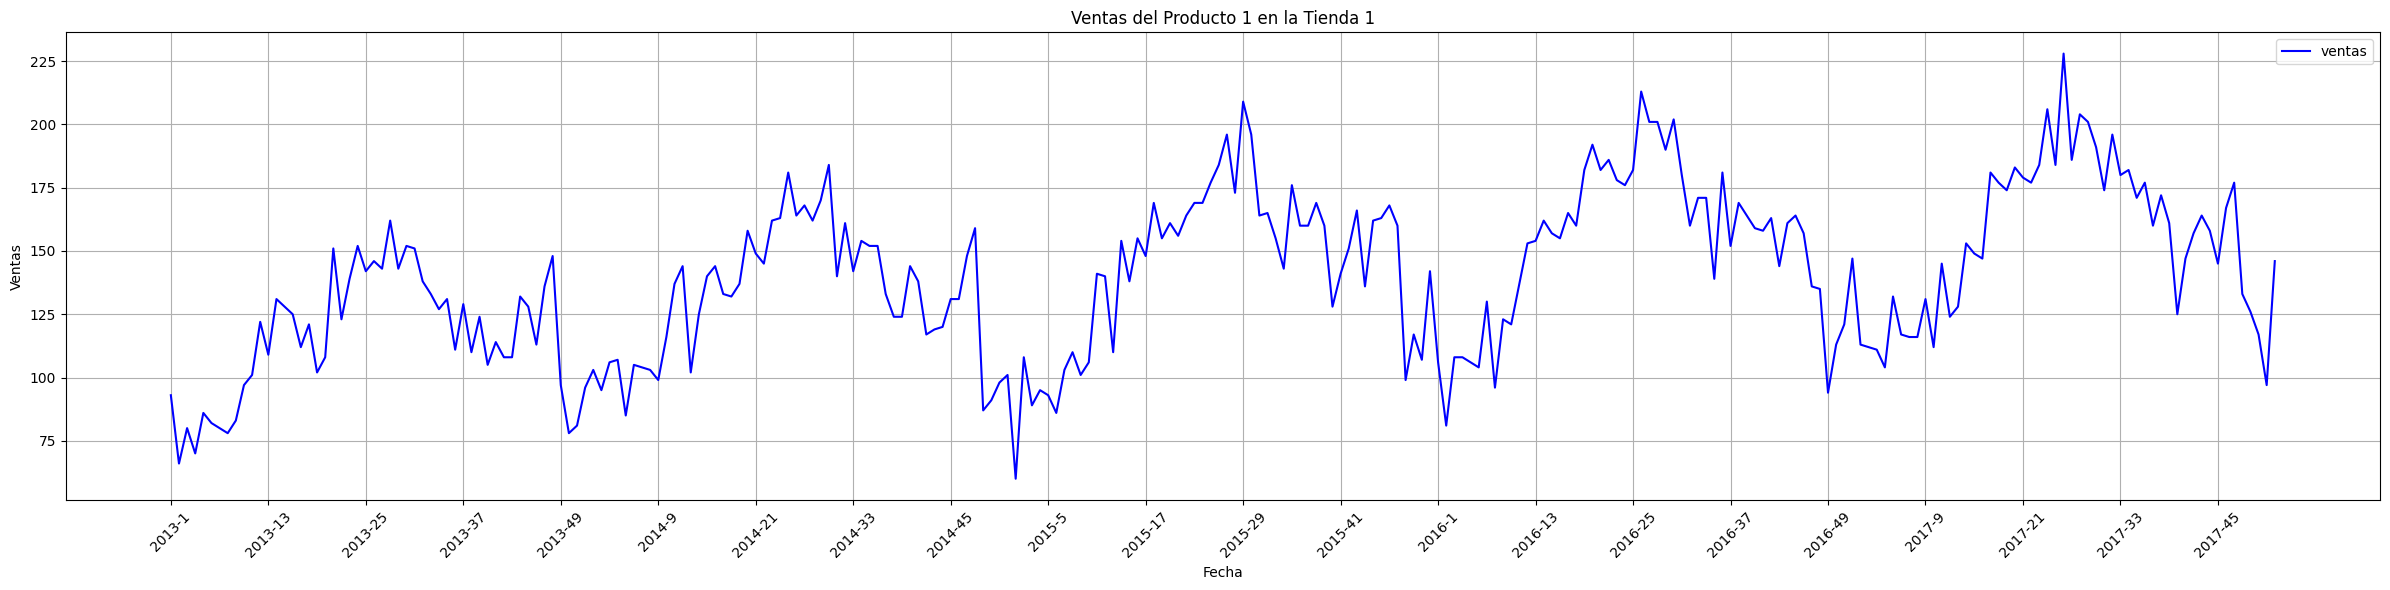

In [156]:
# Crear el gráfico
plt.figure(figsize=(24, 6))
plt.plot(datos.index, datos['ventas'], linestyle='-', color='b', label='ventas')

# Personalizar el gráfico
plt.title('Ventas del Producto 1 en la Tienda 1')
plt.xlabel('Fecha')
plt.ylabel('Ventas')

# Mostrar cada 12 en el eje X 
plt.xticks(datos.index[::12], rotation=45)

plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [157]:
# 80% de entrenamiento (sin contar las últimas 52 semanas)
train_size = len(datos) - 52  # reservamos las últimas 52 semanas para test

# Dividir en entrenamiento y prueba
train = datos.iloc[:train_size]
test = datos.iloc[train_size:]

# Mostrar el número de datos en el conjunto de entrenamiento y prueba
print(f"Número de datos en el conjunto de entrenamiento (train): {train.shape[0]}")
print(f"Número de datos en el conjunto de prueba (test): {test.shape[0]}")

Número de datos en el conjunto de entrenamiento (train): 208
Número de datos en el conjunto de prueba (test): 52


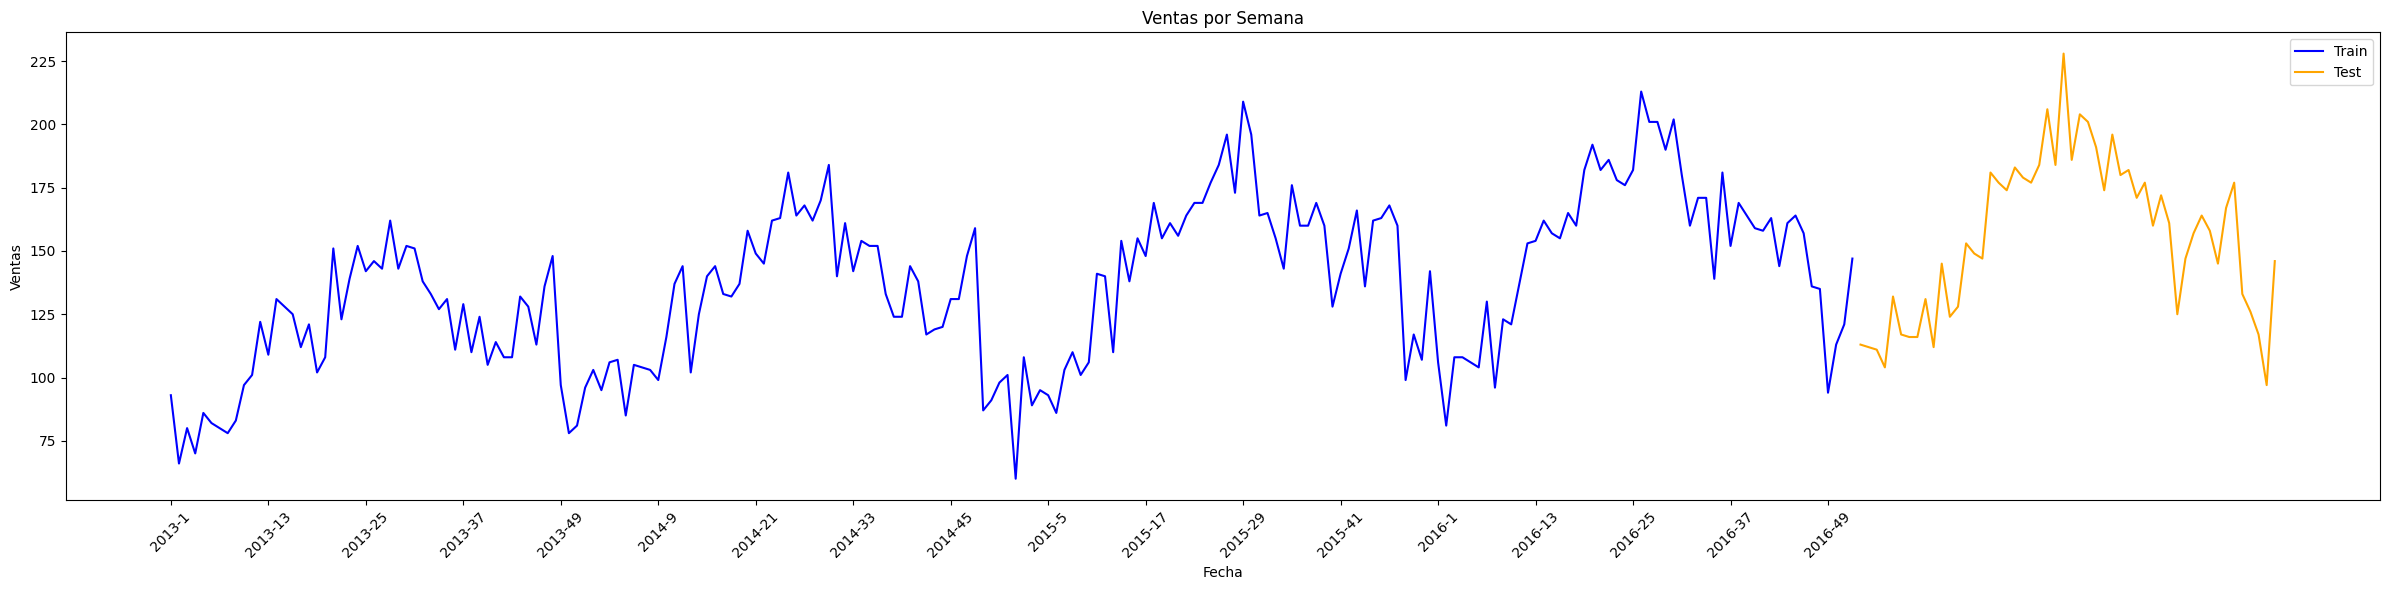

In [158]:
plt.figure(figsize=(24, 6))

# Usar el índice como eje X
plt.plot(train.index, train['ventas'], label='Train', color='blue')
plt.plot(test.index, test['ventas'], label='Test', color='orange')

# Marcar cada 12 semanas en el eje X
plt.xticks(train.index[::12], rotation=45)

plt.title('Ventas por Semana')
plt.xlabel('Fecha')
plt.ylabel('Ventas')

plt.legend()
plt.tight_layout()
plt.show()

<mark>BASELINE</mark>

In [159]:
# Calcular la media móvil en el conjunto de entrenamiento (train)
rolling_window = 4
train["Media_Movil"] = train["ventas"].rolling(window=rolling_window).mean()

In [160]:
# Concatenar las series de ventas de train y test
combined = pd.concat([train["ventas"], test["ventas"]])

# Desplazar la serie para no incluir la observación actual en la media móvil
combined_shifted = combined.shift(1)

# Calcular la media móvil de 4 periodos sobre la serie desplazada
rolling_mean = combined_shifted.rolling(window=rolling_window).mean()

# Crear copia para evitar SettingWithCopyWarning
test = test.copy()

# Asignar las predicciones del baseline a test, usando índices correspondientes
test["PredicciónBaseline"] = rolling_mean.loc[test.index]

In [161]:
# Mostrar los primeros 10 valores de PredicciónBaseline y ventas en test
print(test[["PredicciónBaseline", "ventas"]].head(10))

         PredicciónBaseline  ventas
fecha                              
2017-1               118.75     113
2017-2               123.50     112
2017-3               123.25     111
2017-4               120.75     104
2017-5               110.00     132
2017-6               114.75     117
2017-7               116.00     116
2017-8               117.25     116
2017-9               120.25     131
2017-10              120.00     112


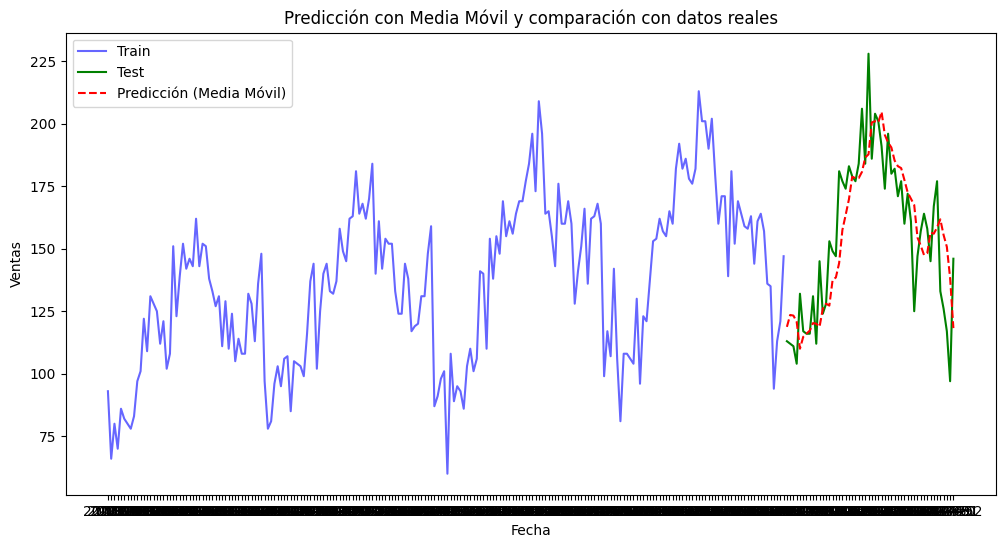

In [162]:
# Gráfico de resultados
plt.figure(figsize=(12, 6))
plt.plot(train.index, train["ventas"], label="Train", color="blue", alpha=0.6)
plt.plot(test.index, test["ventas"], label="Test", color="green")
plt.plot(test.index, test["PredicciónBaseline"], label="Predicción (Media Móvil)", color="red", linestyle="dashed")

plt.legend()
plt.title("Predicción con Media Móvil y comparación con datos reales")
plt.xlabel("Fecha")
plt.ylabel("Ventas")
plt.show()

In [163]:
# Cálculo de métricas de error
mse_baseline = mean_squared_error(test["ventas"], test["PredicciónBaseline"])
mae_baseline = mean_absolute_error(test["ventas"], test["PredicciónBaseline"])
rmse_baseline = np.sqrt(mse_baseline)
mape_baseline = np.mean(np.abs((test["ventas"] - test["PredicciónBaseline"]) / test["ventas"])) * 100

print(f"MSE: {mse_baseline:.2f}")
print(f"MAE: {mae_baseline:.2f}")
print(f"RMSE: {rmse_baseline:.2f}")
print(f"MAPE: {mape_baseline:.2f}%")

MSE: 324.44
MAE: 13.82
RMSE: 18.01
MAPE: 9.46%


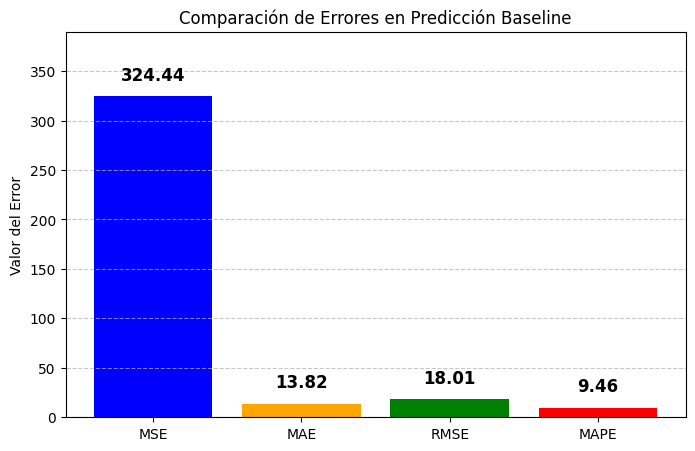

In [164]:
#Gráfico de Errores
plt.figure(figsize=(8, 5))
metricas = ["MSE", "MAE", "RMSE", "MAPE"]
valores = [mse_baseline, mae_baseline, rmse_baseline, mape_baseline]

plt.bar(metricas, valores, color=["blue", "orange", "green", "red"])
plt.title("Comparación de Errores en Predicción Baseline")
plt.ylabel("Valor del Error")
plt.ylim(0, max(valores) * 1.2)  # Ajustar la escala del gráfico
plt.grid(axis="y", linestyle="--", alpha=0.7)

# Mostrar valores en las barras
for i, v in enumerate(valores):
    plt.text(i, v + (max(valores) * 0.05), f"{v:.2f}", ha="center", fontsize=12, fontweight="bold")

plt.show()

<mark>MODELO DE SERIES TEMPORALES</mark>

In [174]:
# Ajustar el modelo AutoARIMA con estacionalidad 
modelo = pm.auto_arima(train['ventas'], 
                                 seasonal=True,
                                 m=1, 
                                 stepwise=True,
                                 trace=True,
                                 suppress_warnings=True)

# Ver el resumen del modelo ajustado
print(modelo.summary())

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=1771.197, Time=0.60 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=1800.651, Time=0.01 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=1772.386, Time=0.03 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=1765.671, Time=0.35 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=1798.692, Time=0.01 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=1767.664, Time=0.41 sec
 ARIMA(0,1,2)(0,0,0)[0] intercept   : AIC=1767.663, Time=0.93 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=1769.224, Time=1.19 sec
 ARIMA(0,1,1)(0,0,0)[0]             : AIC=1763.811, Time=0.03 sec
 ARIMA(1,1,1)(0,0,0)[0]             : AIC=1765.802, Time=0.03 sec
 ARIMA(0,1,2)(0,0,0)[0]             : AIC=1765.802, Time=0.10 sec
 ARIMA(1,1,0)(0,0,0)[0]             : AIC=1770.477, Time=0.11 sec
 ARIMA(1,1,2)(0,0,0)[0]             : AIC=1767.360, Time=0.25 sec

Best model:  ARIMA(0,1,1)(0,0,0)[0]          
Total fit time: 4.068 seconds
                      

In [175]:
predicciones = []
history = train['ventas'].tolist()
modelo_autoarima = modelo

for i in range(len(test)):
    pred = modelo_autoarima.predict(n_periods=1)
    
    if isinstance(pred, pd.Series):
        yhat = pred.iloc[0]
    else:
        yhat = pred[0]
    
    predicciones.append(yhat)

    history.append(test['ventas'].iloc[i])

    modelo_autoarima = pm.auto_arima(history,
                                     seasonal=True,
                                     m=1,
                                     stepwise=True,
                                     suppress_warnings=True,
                                     error_action="ignore",
                                     trace=False)

test["PredicciónSARIMA"] = predicciones

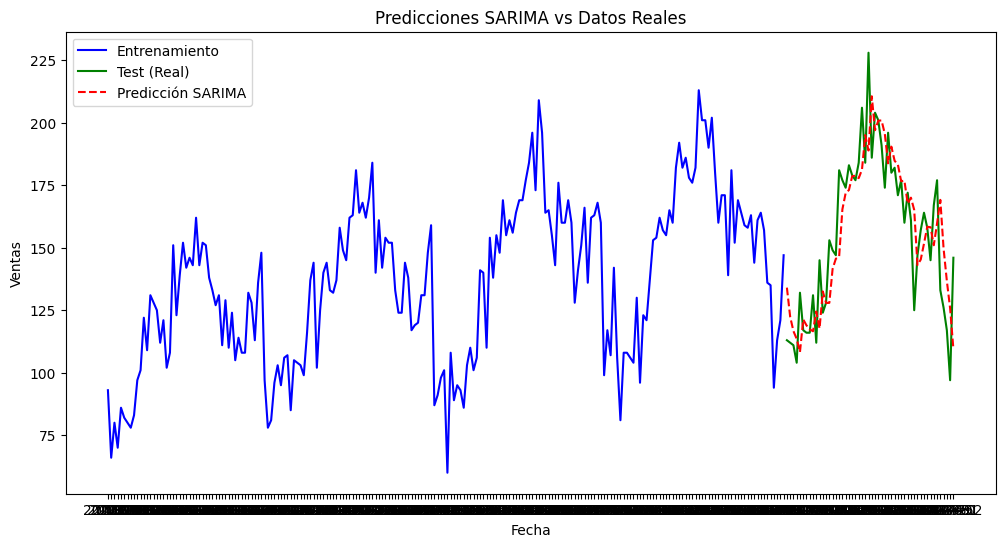

In [176]:
# Graficar las predicciones vs los datos reales de test
warnings.filterwarnings("ignore", category=FutureWarning, message=".*float.*single element.*")

plt.figure(figsize=(12, 6))
plt.plot(train.index, train['ventas'], label="Entrenamiento", color='blue')
plt.plot(test.index, test['ventas'], label="Test (Real)", color='green')
plt.plot(test.index, test["PredicciónSARIMA"], label="Predicción SARIMA", color='red', linestyle='dashed')
plt.legend()
plt.title("Predicciones SARIMA vs Datos Reales")
plt.xlabel("Fecha")
plt.ylabel("Ventas")
plt.show()

In [177]:
# Ignorar los warnings de deprecación
warnings.filterwarnings("ignore", category=DeprecationWarning)

# Cálculo de los errores de predicción
mse_sarima = mean_squared_error(test["ventas"], test["PredicciónSARIMA"])
mae_sarima = mean_absolute_error(test["ventas"], test["PredicciónSARIMA"])
rmse_sarima = np.sqrt(mse_sarima)  
mape_sarima = np.mean(np.abs((test["ventas"] - test["PredicciónSARIMA"]) / test["ventas"])) * 100

# Mostrar los resultados
print(f"MSE (SARIMA): {mse_sarima:.2f}")
print(f"MAE (SARIMA): {mae_sarima:.2f}")
print(f"RMSE (SARIMA): {rmse_sarima:.2f}")
print(f"MAPE (SARIMA): {mape_sarima:.2f}%")

MSE (SARIMA): 306.73
MAE (SARIMA): 13.63
RMSE (SARIMA): 17.51
MAPE (SARIMA): 9.23%


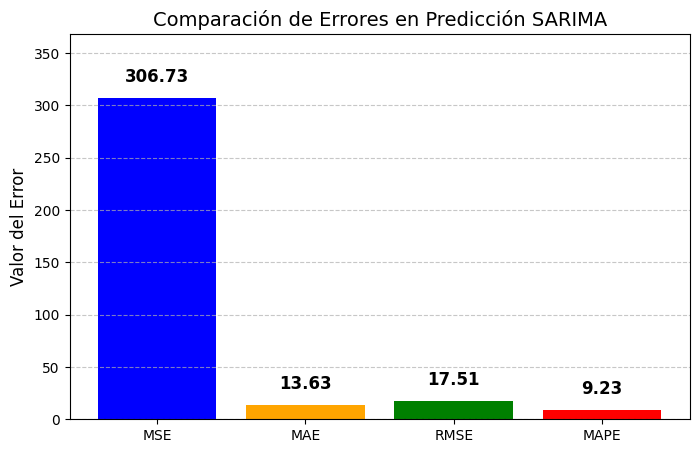

In [178]:
# Lista de métricas de error
metricas = ["MSE", "MAE", "RMSE", "MAPE"]
valores = [mse_sarima, mae_sarima, rmse_sarima, mape_sarima]

# Graficar los errores
plt.figure(figsize=(8, 5))

# Crear barras
plt.bar(metricas, valores, color=["blue", "orange", "green", "red"])

# Título y etiquetas
plt.title("Comparación de Errores en Predicción SARIMA", fontsize=14)
plt.ylabel("Valor del Error", fontsize=12)
plt.ylim(0, max(valores) * 1.2)  # Ajustamos la escala del gráfico para que las barras no se toquen con el límite superior
plt.grid(axis="y", linestyle="--", alpha=0.7)

# Mostrar los valores sobre las barras
for i, v in enumerate(valores):
    plt.text(i, v + (max(valores) * 0.05), f"{v:.2f}", ha="center", fontsize=12, fontweight="bold")

# Mostrar gráfico
plt.show()

<mark>ERRORES COMPARADOS</mark>

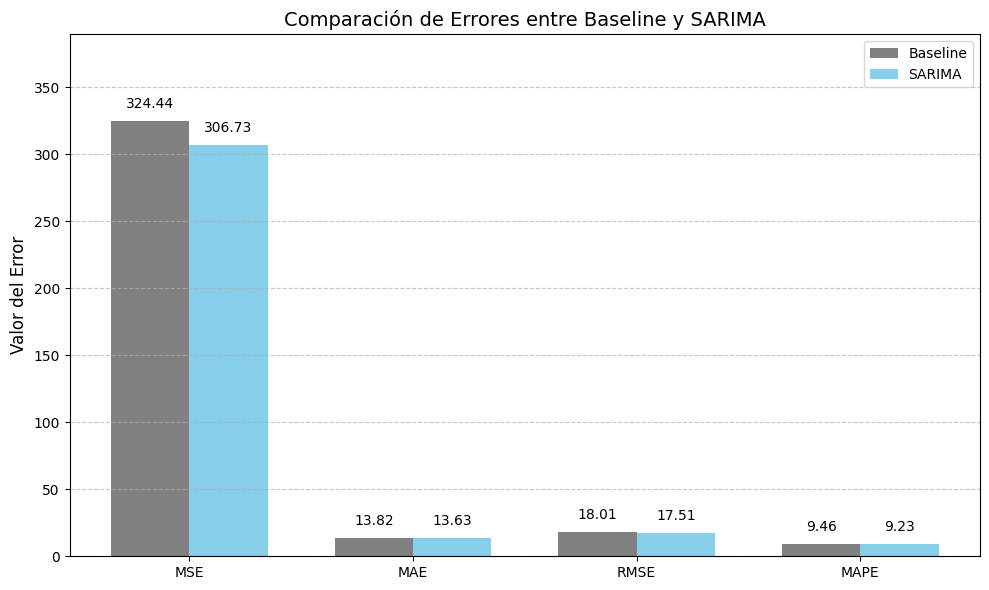

In [179]:
# Métricas
metricas = ["MSE", "MAE", "RMSE", "MAPE"]

# Valores para cada modelo
valores_baseline = [mse_baseline, mae_baseline, rmse_baseline, mape_baseline]
valores_sarima = [mse_sarima, mae_sarima, rmse_sarima, mape_sarima]

# Posiciones de las barras
x = np.arange(len(metricas))
width = 0.35  # Ancho de las barras

# Crear gráfico
plt.figure(figsize=(10, 6))
plt.bar(x - width/2, valores_baseline, width, label="Baseline", color="gray")
plt.bar(x + width/2, valores_sarima, width, label="SARIMA", color="skyblue")

# Etiquetas y estilo
plt.ylabel("Valor del Error", fontsize=12)
plt.title("Comparación de Errores entre Baseline y SARIMA", fontsize=14)
plt.xticks(x, metricas)
plt.ylim(0, max(valores_baseline + valores_sarima) * 1.2)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.legend()

# Mostrar valores sobre las barras
for i in range(len(metricas)):
    plt.text(x[i] - width/2, valores_baseline[i] + 0.03 * max(valores_baseline + valores_sarima), f"{valores_baseline[i]:.2f}", 
             ha='center', fontsize=10, color='black')
    plt.text(x[i] + width/2, valores_sarima[i] + 0.03 * max(valores_baseline + valores_sarima), f"{valores_sarima[i]:.2f}", 
             ha='center', fontsize=10, color='black')

# Mostrar gráfico
plt.tight_layout()
plt.show()

<mark>GRADIENT BOOSTING</mark>

In [180]:
# Forzar el tamaño del conjunto de validación a 53
val_size = 52

# Dividir train en datos_train y datos_val
datos_train = train[:-val_size]
datos_val = train[-val_size:]
datos_test = test

# Mostrar el número de datos en cada conjunto
print(f"Número de datos en el conjunto de entrenamiento (datos_train): {datos_train.shape[0]}")
print(f"Número de datos en el conjunto de validación (datos_val): {datos_val.shape[0]}")
print(f"Número de datos en el conjunto de prueba (datos_test): {datos_test.shape[0]}")

Número de datos en el conjunto de entrenamiento (datos_train): 156
Número de datos en el conjunto de validación (datos_val): 52
Número de datos en el conjunto de prueba (datos_test): 52


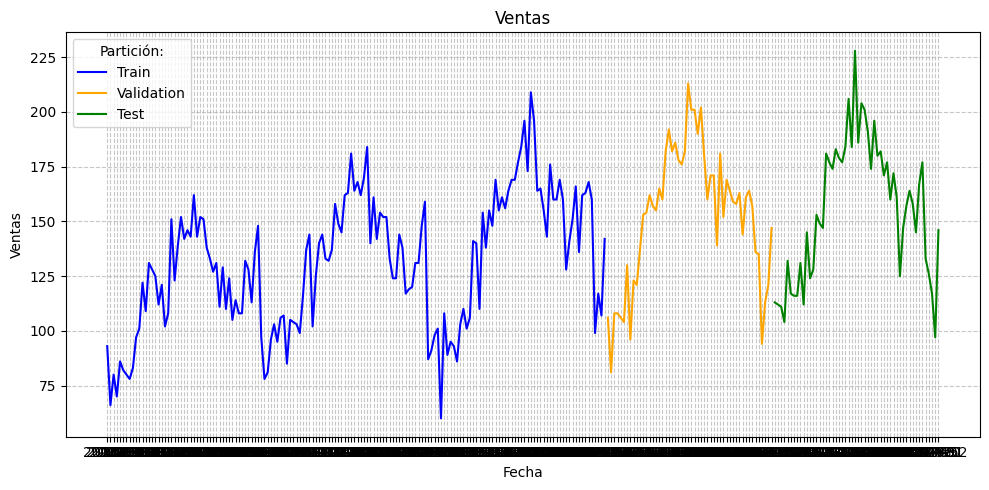

In [181]:
# Crear el gráfico
plt.figure(figsize=(10, 5))

# Graficar las series
plt.plot(datos_train.index, datos_train['ventas'], label='Train', color='blue')
plt.plot(datos_val.index, datos_val['ventas'], label='Validation', color='orange')
plt.plot(datos_test.index, datos_test['ventas'], label='Test', color='green')

# Títulos y leyenda
plt.title('Ventas')
plt.xlabel('Fecha')
plt.ylabel('Ventas')
plt.legend(title='Partición:', loc='upper left')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()

# Mostrar la figura en una ventana local 
plt.show()

In [182]:
fin_validacion = datos_val.index.max()
fin_train = datos_train.index.max()

In [ ]:
#FORECASTER CON LIGHTGBM

In [184]:
# Crear el forecaster
window_features = RollingFeatures(
    stats=["mean", "mean", "mean", "mean"],
    window_sizes=[4, 12, 26, 52]
)


forecaster = ForecasterRecursive(
                regressor       = LGBMRegressor(random_state=15926, verbose=-1),
                lags            = 52, #CAMBIO
                window_features = window_features
             )

# Entrenar el forecaster
forecaster.fit(y=datos.loc[:fin_validacion, 'ventas'])
forecaster

=================== 
ForecasterRecursive 
=================== 
Regressor: LGBMRegressor 
Lags: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24
 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48
 49 50 51 52] 
Window features: ['roll_mean_4', 'roll_mean_12', 'roll_mean_26', 'roll_mean_52'] 
Window size: 52 
Series name: ventas 
Exogenous included: False 
Exogenous names: None 
Transformer for y: None 
Transformer for exog: None 
Weight function included: False 
Differentiation order: None 
Training range: [0, 164] 
Training index type: RangeIndex 
Training index frequency: 1 
Regressor parameters: 
    {'boosting_type': 'gbdt', 'class_weight': None, 'colsample_bytree': 1.0,
    'importance_type': 'split', 'learning_rate': 0.1, 'max_depth': -1,
    'min_child_samples': 20, 'min_child_weight': 0.001, 'min_split_gain': 0.0,
    'n_estimators': 100, 'n_jobs': None, 'num_leaves': 31, 'objective': None,
    'random_state': 15926, 'reg_alpha': 0.0, 'reg_lambda': 0.0, 'subsample':
    1.0, 'subsample_for_bin': 200000, 'subsample_freq': 0, 'verbose': -1} 
fit_kwargs: {} 
Creation date: 2025-06-04 18:02:42 
Last fit date: 2025-06-04 18:02:42 
Skforecast version: 0.16.0 
Python version: 3.9.13 
Forecaster id: None

In [ ]:
# PREDICCIÓN NORMAL (SIN BACKTESTING) Y DEL TAMAÑO DEL TEST
# Predicción en test
predicciones = forecaster.predict(steps=len(datos_test))

# Calcular la métrica MAE comparando predicciones con datos_test
from sklearn.metrics import mean_absolute_error

mae_test = mean_absolute_error(datos_test['ventas'], predicciones)
print(f"MAE en el conjunto de prueba: {mae_test}")

MAE en el conjunto de prueba: 22.210216220821863


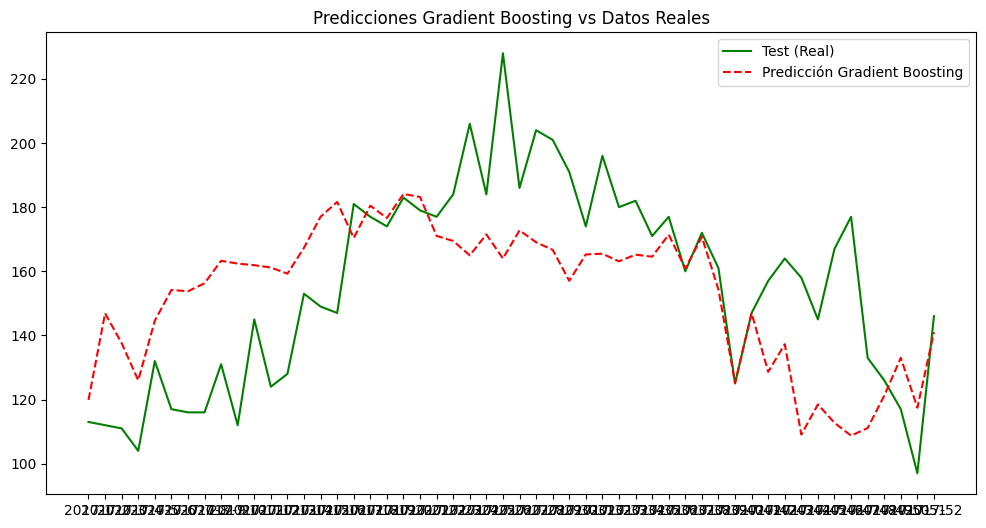

In [186]:
# Seleccionar solo las predicciones correspondientes a los datos del conjunto de prueba
predicciones_test = predicciones[-len(test):]

# Ahora grafica las predicciones junto con los datos reales
plt.figure(figsize=(12, 6))
plt.plot(test.index, test['ventas'], label="Test (Real)", color='green')
plt.plot(test.index, predicciones_test, label="Predicción Gradient Boosting", color='red', linestyle='dashed')
plt.legend()
plt.title("Predicciones Gradient Boosting vs Datos Reales")
plt.show()

In [ ]:
#OPTIMIZACIÓN DE PARÁMETROS

In [187]:
# Definir rolling features
window_features = RollingFeatures(
    stats=["mean","mean","mean","mean"],
    window_sizes=[4, 12, 26, 52]
)

# Definir grids de lags
lags_grid = [
    [1, 2, 3, 4],
    [1, 2, 3, 12],
    [1, 2, 3, 26, 52],
    [4, 8, 12, 26, 52],
    list(range(1, 13)),
    list(range(1, 52))
]

# Espacio de búsqueda limitado (controlado)
def search_space(trial):
    return {
        'n_estimators' : trial.suggest_int('n_estimators', 500, 1500, step=100),
        'max_depth'    : trial.suggest_int('max_depth', 3, 8),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
        'reg_alpha'    : trial.suggest_float('reg_alpha', 0, 0.5, step=0.1),
        'reg_lambda'   : trial.suggest_float('reg_lambda', 0, 0.5, step=0.1),
        'lags'         : trial.suggest_categorical('lags', lags_grid)
    }

# Crear Forecaster base

forecaster = ForecasterRecursive(
    regressor       = LGBMRegressor(objective='regression', random_state=15926, verbose=-1),
    lags            = None,  # Definido en la búsqueda
    window_features = window_features
)

# -----------------------------------------------------------
# Paso 3. Definir esquema de validación expanding window
# -----------------------------------------------------------

cv_search = TimeSeriesFold(
    steps              = 12,  # predices 12 semanas cada vez
    initial_train_size = len(datos[:fin_train]),
    refit              = False
)

# Búsqueda bayesiana de hiperparámetros (simplificada)

y = datos.loc[:fin_validacion, 'ventas'].reset_index(drop=True)


resultados_busqueda, frozen_trial = bayesian_search_forecaster(
    forecaster    = forecaster,
    y             = y,
    cv            = cv_search,
    metric        = 'mean_absolute_error',
    search_space  = search_space,
    n_trials      = 50,  # Menos trials, más rápido
    random_state  = 123,
    return_best   = True,
    n_jobs        = 'auto',
    verbose       = True,
    show_progress = True
)

print("Búsqueda de hiperparámetros finalizada.")

  0%|          | 0/50 [00:00<?, ?it/s]

Information of folds
--------------------
Number of observations used for initial training: 113
Number of observations used for backtesting: 52
    Number of folds: 5
    Number skipped folds: 0 
    Number of steps per fold: 12
    Number of steps to exclude between last observed data (last window) and predictions (gap): 0
    Last fold only includes 4 observations.

Fold: 0
    Training:   0 -- 112  (n=113)
    Validation: 113 -- 124  (n=12)
Fold: 1
    Training:   No training in this fold
    Validation: 125 -- 136  (n=12)
Fold: 2
    Training:   No training in this fold
    Validation: 137 -- 148  (n=12)
Fold: 3
    Training:   No training in this fold
    Validation: 149 -- 160  (n=12)
Fold: 4
    Training:   No training in this fold
    Validation: 161 -- 164  (n=4)



Best trial: 1. Best value: 21.1913:   4%|▍         | 2/50 [00:00<00:09,  4.87it/s]

Information of folds
--------------------
Number of observations used for initial training: 113
Number of observations used for backtesting: 52
    Number of folds: 5
    Number skipped folds: 0 
    Number of steps per fold: 12
    Number of steps to exclude between last observed data (last window) and predictions (gap): 0
    Last fold only includes 4 observations.

Fold: 0
    Training:   0 -- 112  (n=113)
    Validation: 113 -- 124  (n=12)
Fold: 1
    Training:   No training in this fold
    Validation: 125 -- 136  (n=12)
Fold: 2
    Training:   No training in this fold
    Validation: 137 -- 148  (n=12)
Fold: 3
    Training:   No training in this fold
    Validation: 149 -- 160  (n=12)
Fold: 4
    Training:   No training in this fold
    Validation: 161 -- 164  (n=4)

Information of folds
--------------------
Number of observations used for initial training: 113
Number of observations used for backtesting: 52
    Number of folds: 5
    Number skipped folds: 0 
    Number of steps 

Best trial: 1. Best value: 21.1913:   8%|▊         | 4/50 [00:00<00:07,  6.37it/s]

...

Information of folds
--------------------
Number of observations used for initial training: 113
Number of observations used for backtesting: 52
    Number of folds: 5
    Number skipped folds: 0 
    Number of steps per fold: 12
    Number of steps to exclude between last observed data (last window) and predictions (gap): 0
    Last fold only includes 4 observations.

Fold: 0
    Training:   0 -- 112  (n=113)
    Validation: 113 -- 124  (n=12)
Fold: 1
    Training:   No training in this fold
    Validation: 125 -- 136  (n=12)
Fold: 2
    Training:   No training in this fold
    Validation: 137 -- 148  (n=12)
Fold: 3
    Training:   No training in this fold
    Validation: 149 -- 160  (n=12)
Fold: 4
    Training:   No training in this fold
    Validation: 161 -- 164  (n=4)

Information of folds
--------------------
Number of observations used for initial training: 113
Number of observations used for backtesting: 52
    Number of folds: 5
    Number skipped folds: 0 
    Number of steps 

Best trial: 13. Best value: 19.1531:  96%|█████████▌| 48/50 [00:09<00:00,  5.05it/s]

Information of folds
--------------------
Number of observations used for initial training: 113
Number of observations used for backtesting: 52
    Number of folds: 5
    Number skipped folds: 0 
    Number of steps per fold: 12
    Number of steps to exclude between last observed data (last window) and predictions (gap): 0
    Last fold only includes 4 observations.

Fold: 0
    Training:   0 -- 112  (n=113)
    Validation: 113 -- 124  (n=12)
Fold: 1
    Training:   No training in this fold
    Validation: 125 -- 136  (n=12)
Fold: 2
    Training:   No training in this fold
    Validation: 137 -- 148  (n=12)
Fold: 3
    Training:   No training in this fold
    Validation: 149 -- 160  (n=12)
Fold: 4
    Training:   No training in this fold
    Validation: 161 -- 164  (n=4)

Information of folds
--------------------
Number of observations used for initial training: 113
Number of observations used for backtesting: 52
    Number of folds: 5
    Number skipped folds: 0 
    Number of steps 

Best trial: 13. Best value: 19.1531: 100%|██████████| 50/50 [00:10<00:00,  4.95it/s]

Information of folds
--------------------
Number of observations used for initial training: 113
Number of observations used for backtesting: 52
    Number of folds: 5
    Number skipped folds: 0 
    Number of steps per fold: 12
    Number of steps to exclude between last observed data (last window) and predictions (gap): 0
    Last fold only includes 4 observations.

Fold: 0
    Training:   0 -- 112  (n=113)
    Validation: 113 -- 124  (n=12)
Fold: 1
    Training:   No training in this fold
    Validation: 125 -- 136  (n=12)
Fold: 2
    Training:   No training in this fold
    Validation: 137 -- 148  (n=12)
Fold: 3
    Training:   No training in this fold
    Validation: 149 -- 160  (n=12)
Fold: 4
    Training:   No training in this fold
    Validation: 161 -- 164  (n=4)

`Forecaster` refitted using the best-found lags and parameters, and the whole data set: 
  Lags: [ 4  8 12 26 52] 
  Parameters: {'n_estimators': 1100, 'max_depth': 7, 'learning_rate': 0.010443122103993943, 'reg_alph

In [123]:
best_params = resultados_busqueda.at[0, 'params']
best_lags   = resultados_busqueda.at[0, 'lags']
best_params |= {'random_state': 15926, 'verbose': -1}

forecaster = ForecasterRecursive(
    regressor       = LGBMRegressor(**best_params),
    lags            = best_lags,
    window_features = window_features
)

# Entrenar forecaster final
forecaster.fit(y=datos.loc[:fin_validacion, 'ventas'])

╭──────────────────────────────────── IndexWarning ────────────────────────────────────╮
│ Series has an unsupported index type (not pandas DatetimeIndex or RangeIndex). The   │
│ index will be replaced by a RangeIndex starting from 0 with a step of 1. To avoid    │
│ this warning, ensure that `y.index` is a DatetimeIndex with a frequency or a         │
│ RangeIndex.                                                                          │
│                                                                                      │
│ Category : IndexWarning                                                              │
│ Location :                                                                           │
│ C:\Users\Daniel\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.9_qbz5n2kfr │
│ a8p0\LocalCache\local-packages\Python39\site-packages\skforecast\utils\utils.py:1402 │
│ Suppress : warnings.simplefilter('ignore', category=IndexWarning)                    │
╰──────────────────────────────────────────────────────────────────────────────────────╯

In [188]:
# Predicciones sobre el test
predicciones = forecaster.predict(steps=len(datos_test))

# Calcular error en Test
from sklearn.metrics import mean_absolute_error

mae_test = mean_absolute_error(datos_test['ventas'], predicciones)

print(f"MAE final en TEST: {mae_test:.3f}")

MAE final en TEST: 26.237


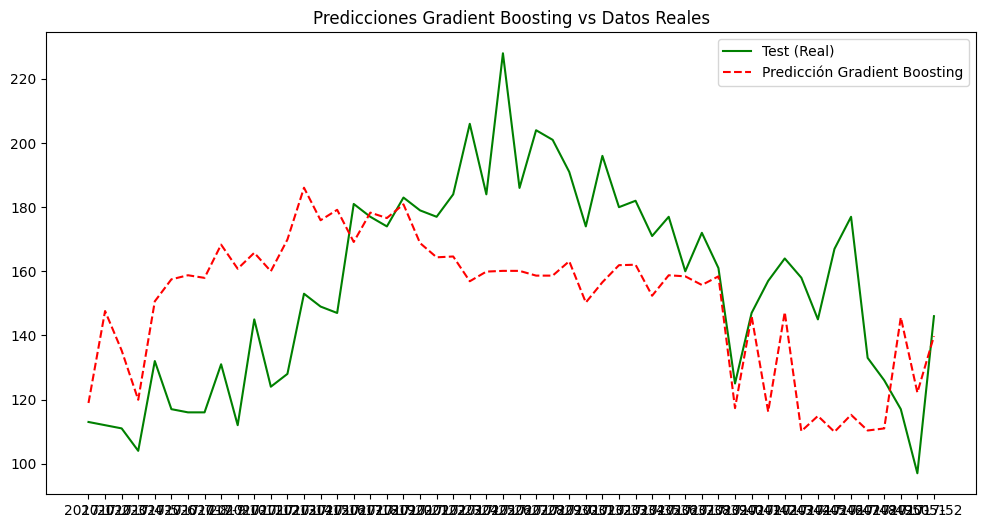

In [189]:
# Ahora grafica las predicciones junto con los datos reales
plt.figure(figsize=(12, 6))
plt.plot(test.index, test['ventas'], label="Test (Real)", color='green')
plt.plot(test.index, predicciones, label="Predicción Gradient Boosting", color='red', linestyle='dashed')
plt.legend()
plt.title("Predicciones Gradient Boosting vs Datos Reales")
plt.show()

VARIABLES EXÓGENAS ASOCIADAS A LA SERIE

In [190]:
datos

,ventas
fecha,
2013-1,93
2013-2,66
2013-3,80
2013-4,70
2013-5,86
...,...
2017-48,133
2017-49,126
2017-50,117


In [191]:
# Leer archivo CSV con separador punto y coma (;)
datos2 = pd.read_csv("demanda.csv", sep=";")

# Mostrar las primeras 5 filas
print(datos2.head())

         date  store  item  sales
0  01/01/2013      1     1     13
1  02/01/2013      1     1     11
2  03/01/2013      1     1     14
3  04/01/2013      1     1     13
4  05/01/2013      1     1     10


In [192]:
# Filtrar solo producto 1 y tienda 1
datos2 = datos2[(datos2['item'] == 1) & (datos2['store'] == 1)]

# Convertir la columna 'date' a tipo datetime (formato día/mes/año)
datos2['date'] = pd.to_datetime(datos2['date'], format='%d/%m/%Y')

# Extraer año y semana del año
datos2['Año'] = datos2['date'].dt.year
datos2['Semana'] = datos2['date'].dt.isocalendar().week

# Crear columna 'fecha' que concatena año y semana con guion
datos2['fecha'] = datos2['Año'].astype(str) + '-' + datos2['Semana'].astype(str)

# Mostrar las primeras 10 filas
print(datos2.head(10))

        date  store  item  sales   Año  Semana   fecha
0 2013-01-01      1     1     13  2013       1  2013-1
1 2013-01-02      1     1     11  2013       1  2013-1
2 2013-01-03      1     1     14  2013       1  2013-1
3 2013-01-04      1     1     13  2013       1  2013-1
4 2013-01-05      1     1     10  2013       1  2013-1
5 2013-01-06      1     1     12  2013       1  2013-1
6 2013-01-07      1     1     10  2013       2  2013-2
7 2013-01-08      1     1      9  2013       2  2013-2
8 2013-01-09      1     1     12  2013       2  2013-2
9 2013-01-10      1     1      9  2013       2  2013-2


In [193]:
datos_semanal = datos2.groupby("fecha")["sales"].sum().reset_index().rename(columns={"sales": "ventas"})

In [194]:
# Separar 'fecha' en año y semana
datos_semanal[['year', 'week']] = datos_semanal['fecha'].str.split('-', expand=True).astype(int)

# Crear columna con la fecha del primer día de la semana (lunes)
# Para eso usamos pandas.Timestamp y pd.to_datetime con formato ISO de semana

def get_first_day_of_week(row):
    return pd.to_datetime(f'{row.year}-W{row.week - 1}-1', format='%Y-W%W-%w')

datos_semanal['fecha_date'] = datos_semanal.apply(get_first_day_of_week, axis=1)

# Ordenar por la fecha calculada
datos_semanal = datos_semanal.sort_values('fecha_date')

# Mostrar los primeros 15 registros
print(datos_semanal.head(15))

      fecha  ventas  year  week fecha_date
0    2013-1      93  2013     1 2012-12-31
11   2013-2      66  2013     2 2013-01-07
22   2013-3      80  2013     3 2013-01-14
33   2013-4      70  2013     4 2013-01-21
44   2013-5      86  2013     5 2013-01-28
48   2013-6      82  2013     6 2013-02-04
49   2013-7      80  2013     7 2013-02-11
50   2013-8      78  2013     8 2013-02-18
51   2013-9      83  2013     9 2013-02-25
1   2013-10      97  2013    10 2013-03-04
2   2013-11     101  2013    11 2013-03-11
3   2013-12     122  2013    12 2013-03-18
4   2013-13     109  2013    13 2013-03-25
5   2013-14     131  2013    14 2013-04-01
6   2013-15     128  2013    15 2013-04-08


In [195]:
datos_semanal

,fecha,ventas,year,week,fecha_date
0,2013-1,93,2013,1,2012-12-31
11,2013-2,66,2013,2,2013-01-07
22,2013-3,80,2013,3,2013-01-14
33,2013-4,70,2013,4,2013-01-21
44,2013-5,86,2013,5,2013-01-28
...,...,...,...,...,...
252,2017-48,133,2017,48,2017-11-20
253,2017-49,126,2017,49,2017-11-27
255,2017-50,117,2017,50,2017-12-04
256,2017-51,97,2017,51,2017-12-11


In [196]:
# Asegurar que 'fecha_date' sea datetime
datos_semanal['fecha_date'] = pd.to_datetime(datos_semanal['fecha_date'])

# Ordenar por 'fecha_date'
datos_semanal = datos_semanal.sort_values('fecha_date').reset_index(drop=True)

# Extraer mes
datos_semanal['month'] = datos_semanal['fecha_date'].dt.month

# Dividir en train y test (80% train)
train_size = int(len(datos_semanal) * 0.8)
train = datos_semanal.iloc[:train_size]
test  = datos_semanal.iloc[train_size:]

# Validación tamaño (53 semanas)
val_size = 52

# Separar train en train y validación
datos_train = train.iloc[:-val_size]
datos_val   = train.iloc[-val_size:]
datos_test  = test

# Índices máximos de train y validación
fin_train = datos_train.index.max()
fin_validacion = datos_val.index.max()

# Convertir columnas a float
cols_to_float = ['ventas', 'year', 'month', 'week']
for col in cols_to_float:
    datos_semanal[col] = pd.to_numeric(datos_semanal[col], errors='coerce').astype(float)

# Eliminar filas con ventas NaN
datos_semanal = datos_semanal.dropna(subset=['ventas'])

In [197]:
datos_semanal

,fecha,ventas,year,week,fecha_date,month
0,2013-1,93.0,2013.0,1.0,2012-12-31,12.0
1,2013-2,66.0,2013.0,2.0,2013-01-07,1.0
2,2013-3,80.0,2013.0,3.0,2013-01-14,1.0
3,2013-4,70.0,2013.0,4.0,2013-01-21,1.0
4,2013-5,86.0,2013.0,5.0,2013-01-28,1.0
...,...,...,...,...,...,...
257,2017-48,133.0,2017.0,48.0,2017-11-20,11.0
258,2017-49,126.0,2017.0,49.0,2017-11-27,11.0
259,2017-50,117.0,2017.0,50.0,2017-12-04,12.0
260,2017-51,97.0,2017.0,51.0,2017-12-11,12.0


In [210]:
warnings.filterwarnings("ignore")  

# 1. Definir las columnas exógenas
exog_variables = ['year','month']

# 2. Crear rolling features (opcional pero recomendado)
window_features = RollingFeatures(
    stats=["mean", "mean","mean","mean"],
    window_sizes=[4, 12, 26, 52]
)

# 3. Crear el Forecaster
forecaster = ForecasterRecursive(
    regressor       = LGBMRegressor(random_state=15926, verbose=-1),
    lags            = 53,  # Hasta 1 año de lags (semanales)
    window_features = window_features
)

# 4. Entrenar el Forecaster
forecaster.fit(
    y    = datos_semanal.loc[:fin_validacion, 'ventas'],
    exog = datos_semanal.loc[:fin_validacion, exog_variables]
)

print("Forecaster entrenado correctamente.")

# 5. Hacer predicciones en el conjunto de test
predicciones = forecaster.predict(
    steps = len(datos_test),
    exog  = datos_test[exog_variables]
)

# 6. Evaluar el modelo
mae_test = mean_absolute_error(datos_test['ventas'], predicciones)

print(f"MAE final en TEST: {mae_test:.3f}")

Forecaster entrenado correctamente.
MAE final en TEST: 13.456


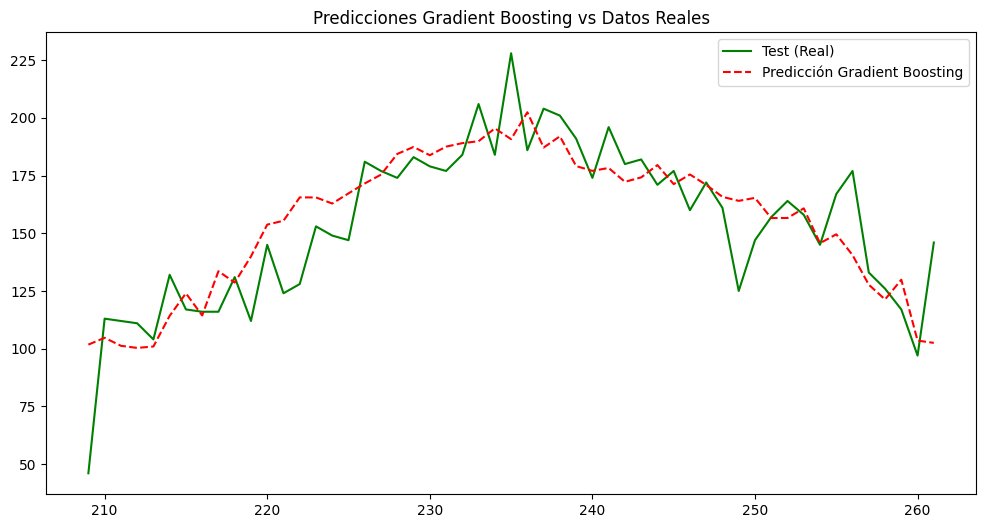

In [208]:
# Ahora grafica las predicciones junto con los datos reales
plt.figure(figsize=(12, 6))
plt.plot(test.index, test['ventas'], label="Test (Real)", color='green')
plt.plot(test.index, predicciones, label="Predicción Gradient Boosting", color='red', linestyle='dashed')
plt.legend()
plt.title("Predicciones Gradient Boosting vs Datos Reales")
plt.show()

ERRORES COMPARADOS

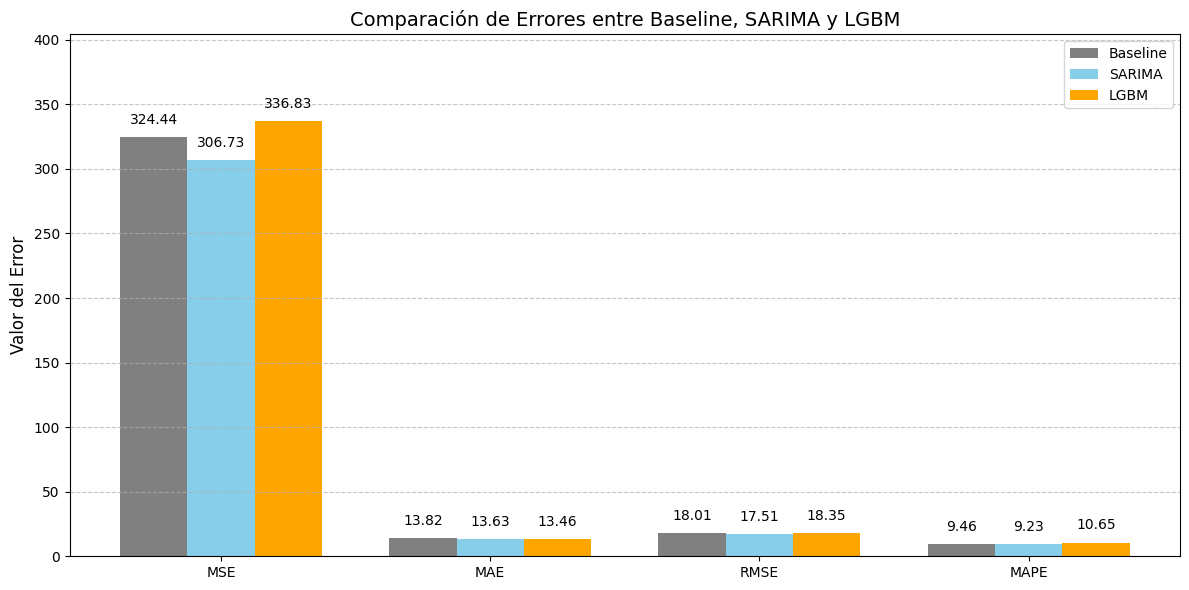

In [211]:
# 1. Calcular métricas para el modelo LGBM
mse_lgbm = mean_squared_error(datos_test['ventas'], predicciones)
mae_lgbm = mean_absolute_error(datos_test['ventas'], predicciones)
rmse_lgbm = np.sqrt(mse_lgbm)
mape_lgbm = np.mean(np.abs((datos_test['ventas'] - predicciones) / datos_test['ventas'])) * 100

# 2. Crear listas con valores de todos los modelos (añadiendo LGBM)
valores_lgbm = [mse_lgbm, mae_lgbm, rmse_lgbm, mape_lgbm]

# 3. Posiciones y configuración barras para 3 modelos
x = np.arange(len(metricas))
width = 0.25  # Ajustar para 3 barras

# 4. Gráfico comparativo
plt.figure(figsize=(12, 6))
plt.bar(x - width, valores_baseline, width, label="Baseline", color="gray")
plt.bar(x, valores_sarima, width, label="SARIMA", color="skyblue")
plt.bar(x + width, valores_lgbm, width, label="LGBM", color="orange")

# 5. Etiquetas y estilo
plt.ylabel("Valor del Error", fontsize=12)
plt.title("Comparación de Errores entre Baseline, SARIMA y LGBM", fontsize=14)
plt.xticks(x, metricas)
plt.ylim(0, max(valores_baseline + valores_sarima + valores_lgbm) * 1.2)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.legend()

# 6. Mostrar valores sobre las barras
max_val = max(valores_baseline + valores_sarima + valores_lgbm)
for i in range(len(metricas)):
    plt.text(x[i] - width, valores_baseline[i] + 0.03 * max_val, f"{valores_baseline[i]:.2f}", 
             ha='center', fontsize=10, color='black')
    plt.text(x[i], valores_sarima[i] + 0.03 * max_val, f"{valores_sarima[i]:.2f}", 
             ha='center', fontsize=10, color='black')
    plt.text(x[i] + width, valores_lgbm[i] + 0.03 * max_val, f"{valores_lgbm[i]:.2f}", 
             ha='center', fontsize=10, color='black')

plt.tight_layout()
plt.show()